In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/"

In [ ]:
# =============
# Data Load
 
import os
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.colors as colors


# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

num_points = 5000  # Número de puntos en cada espectro, para interpolar los datos que le pasamos

# Cargar los datos
data_file = r'data/spectra_data_complete100000.pkl'
with open(data_file, 'rb') as f:
    spectra_data = pickle.load(f)

Usando dispositivo: cuda


In [ ]:
# =============
# Model Evaluation
 
# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Tras 3 max pooling, la dimensión se reduce en un factor de 8
        conv_output_size = num_points // 8
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)

# Definir la función de pérdida
criterion = nn.MSELoss()

# Utilizar Adam con un weight decay para regularización L2
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)

# Scheduler adaptativo: ReduceLROnPlateau reduce la lr si la pérdida de validación no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

c:\Users\alfa\anaconda3\envs\TFGF\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Correlación lineal: 0.9182156363114017


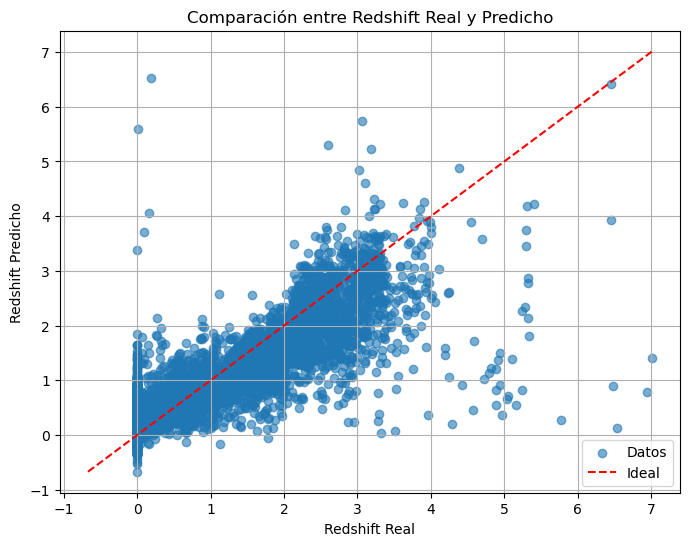

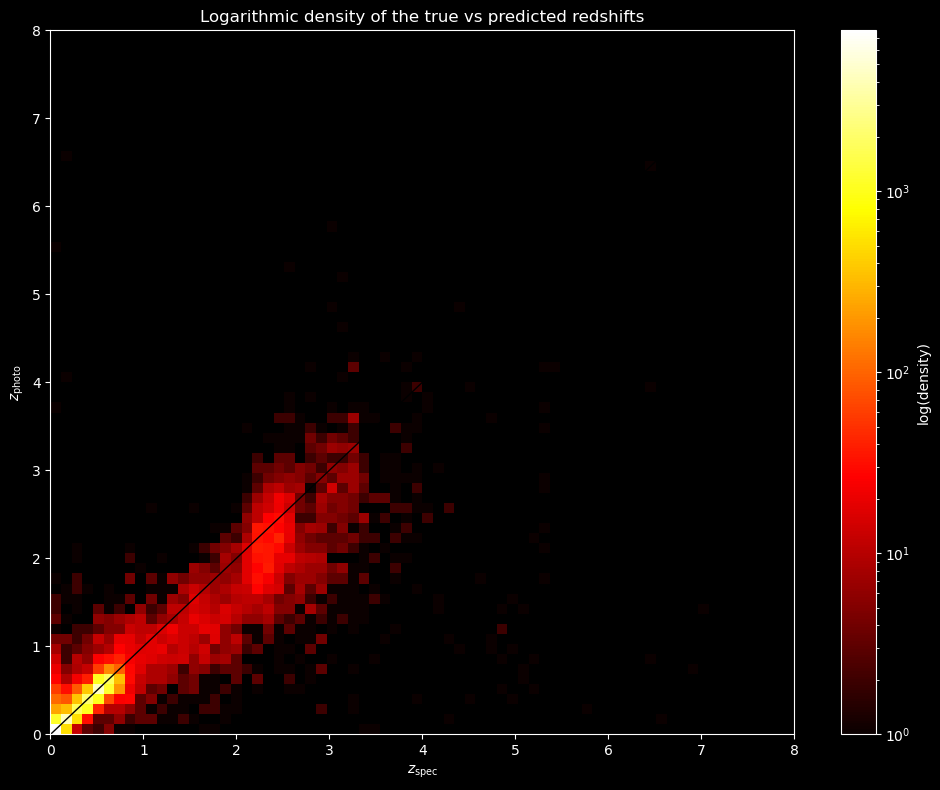

In [ ]:
# Cargar el modelo

# Definir el directorio de destino
model_file_path = 'storage/modelCNN_fullbig_UPD2.pth'

modelCNN = CNN(num_points).to(device)
modelCNN.load_state_dict(torch.load(model_file_path))

spectra_data = spectra_data
file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelength = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelength], axis=1) # Ahora tiene 10000 características por muestra
yreal = np.array(redshifts)

# Normalización
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(nsamples, nchannels, npoints)

# Convertir a tensor
x_test_tensor = torch.tensor(X, dtype=torch.float32)
x_test_tensor = x_test_tensor.to(device)

# Evaluar el modelo
batch_size = 256  # Ajusta este valor según tu GPU
n_samples = x_test_tensor.size(0)

all_preds = []
modelCNN.eval()
with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        x_batch = x_test_tensor[i : i + batch_size]
        preds = modelCNN(x_batch).cpu().numpy()
        all_preds.append(preds)

ypredicted = np.concatenate(all_preds, axis=0)

lincorr = np.corrcoef(yreal, np.transpose(ypredicted))
print(f"Correlación lineal: {lincorr[0, 1]}")




plt.rcdefaults()
plt.figure(figsize=(8, 6))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.show()







# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

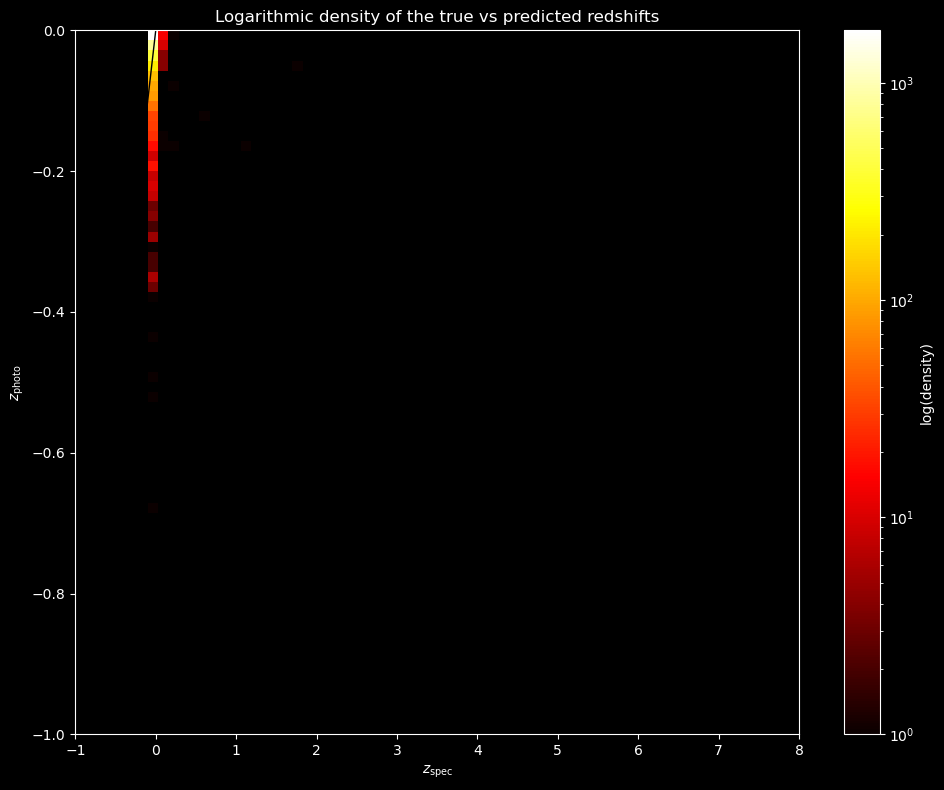

In [ ]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

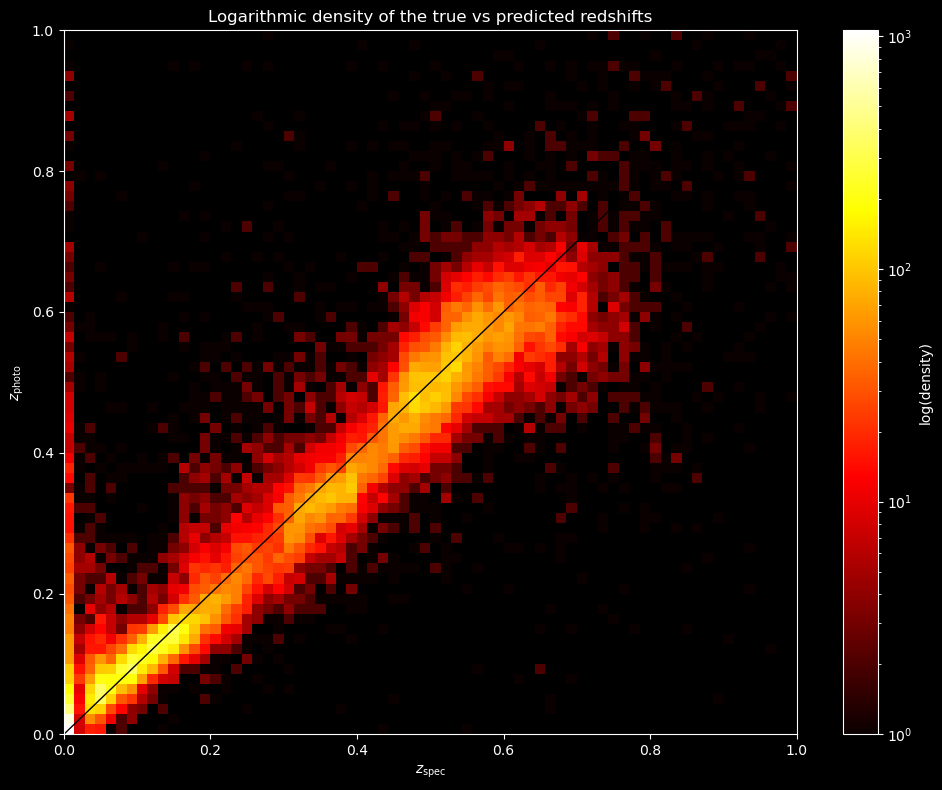

In [ ]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

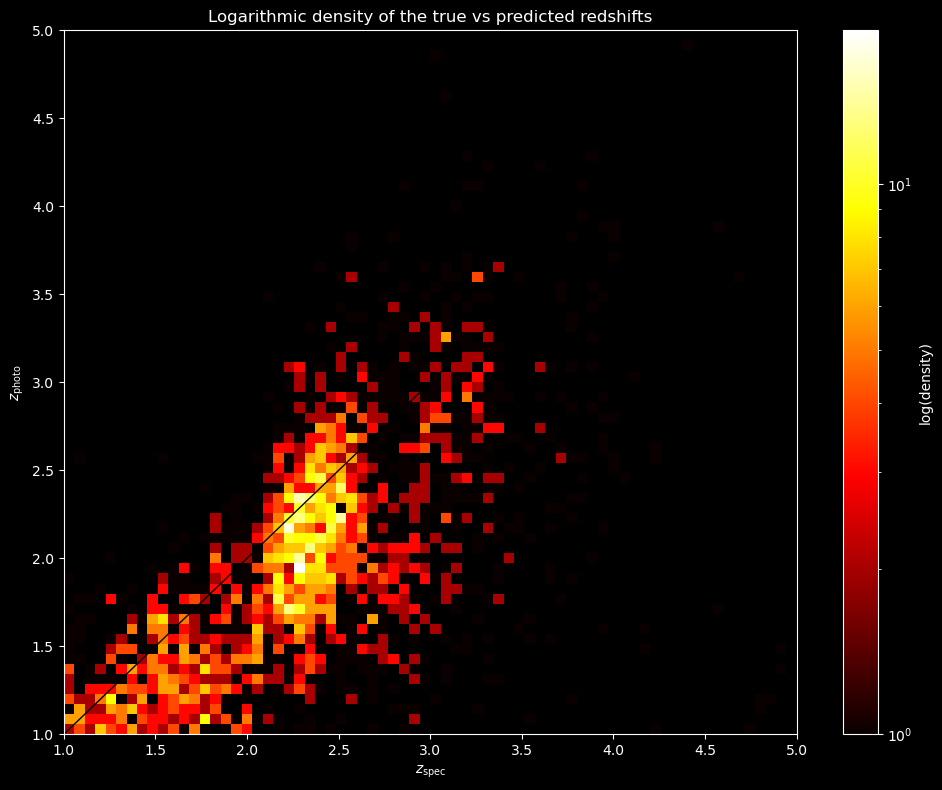

In [ ]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

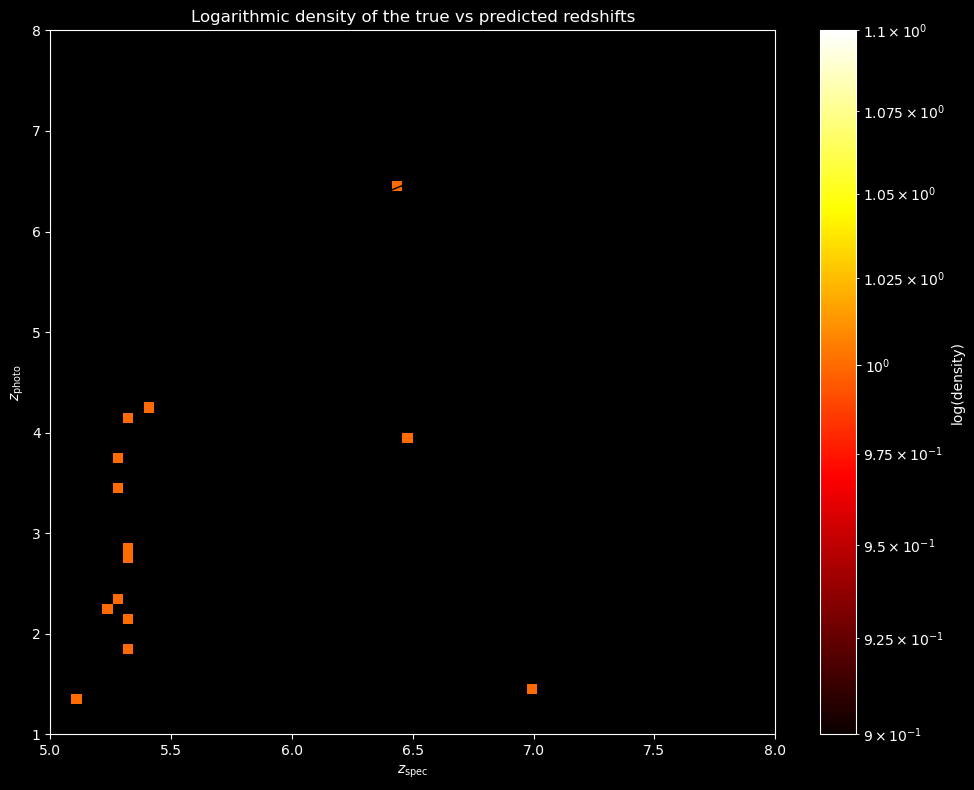

: 

In [ ]:
# Estilo de fondo oscuro (opcional)
plt.style.use('dark_background')

# Rango de ejes (ajústalo a tus necesidades)
x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(10, 8))

# Generamos el histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                # z_spec (redshift "real")
    ypredicted[:, 0],     # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

# Barra de color con etiqueta
cbar = plt.colorbar(im, label='log(density)')

# Trazamos la línea diagonal z_spec = z_photo
plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)

# Etiquetas de ejes
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')

# Título (opcional)
plt.title('Logarithmic density of the true vs predicted redshifts')

# Ajustamos los límites para que coincidan con el rango
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()